# 04_Evaluación e Interpretación de Resultados

**Objetivo**: Evaluar el rendimiento del modelo entrenado en el notebook anterior y utilizar **SHAP** (SHapley Additive exPlanations) para interpretar sus predicciones. Esto nos permitirá:
- Identificar qué características son más influyentes en la decisión del modelo.
- Entender por qué el modelo acierta o falla en casos concretos.
- Generar confianza en el modelo mediante explicaciones visuales.

**Contexto**: En el sector nuclear, la interpretabilidad es tan importante como la precisión. Un modelo de caja negra no sería aceptable; necesitamos entender por qué predice un accidente para que los operadores puedan validar la decisión.

---

## 1. Configuración inicial

Importamos las librerías necesarias, configuramos el proyecto y definimos las rutas.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Añadir la raíz del proyecto al path para importar src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.model import cargar_modelo, plot_waterfall, calcular_shap_values
from src.utils import crear_carpeta, cargar_dataset

# ===== PARÁMETROS =====
DATA_PATH = "../data/processed/features_12sensores_1217muestras.csv"
MODEL_PATH = "../results/modelos/modelo_rf.joblib"
COLUMNAS_PATH = "../results/columnas_seleccionadas.txt"
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Crear carpeta para imágenes
crear_carpeta("../results/imagenes/")
print("✅ Configuración completada.\n")

✅ Configuración completada.



## 2. Carga de datos y modelo
Cargamos el dataset y el modelo entrenado. Filtramos `X_test` para quedarnos solo con las columnas que el modelo espera (las 64 seleccionadas en el notebook anterior).

In [2]:
print("=== Cargando dataset ===")
X_full, y_encoded, le = cargar_dataset(DATA_PATH)
print(f"Dataset cargado: {X_full.shape[0]} filas, {X_full.shape[1]+1} columnas")

# Dividir en train/test (misma semilla)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("\n=== Cargando modelo ===")
modelo = cargar_modelo(MODEL_PATH)

# Obtener columnas del modelo
if hasattr(modelo, 'feature_names_in_'):
    columnas_modelo = list(modelo.feature_names_in_)
    print(f"Modelo cargado con {len(columnas_modelo)} características.")
else:
    columnas_modelo = np.loadtxt(COLUMNAS_PATH, dtype=str).tolist()
    print(f"Columnas cargadas desde archivo: {len(columnas_modelo)}")

X_test_top = X_test[columnas_modelo]

=== Cargando dataset ===
Dataset cargado: 1217 filas, 110 columnas

=== Cargando modelo ===
Modelo cargado con 61 características.


## 3. Evaluación del modelo en test
Calculamos el accuracy, el classification report (por clase) y la matriz de confusión. Esto nos da una visión global del rendimiento y nos permite identificar qué clases se confunden.


=== Evaluación del modelo ===
Accuracy en test: 0.9713

Classification Report (clases en test):
              precision    recall  f1-score   support

         FLB       1.00      1.00      1.00        17
         LLB       1.00      1.00      1.00        21
        LOCA       1.00      1.00      1.00        19
       LOCAC       1.00      1.00      1.00        19
          LR       0.96      1.00      0.98        24
          MD       0.92      0.86      0.89        14
      Normal       0.00      0.00      0.00         1
          RI       0.92      1.00      0.96        24
          RW       1.00      0.91      0.95        22
       SGATR       1.00      1.00      1.00        22
       SGBTR       1.00      1.00      1.00        25
       SLBIC       1.00      1.00      1.00        22
       SLBOC       0.86      0.86      0.86        14

   micro avg       0.98      0.97      0.97       244
   macro avg       0.90      0.89      0.90       244
weighted avg       0.97      0.97    

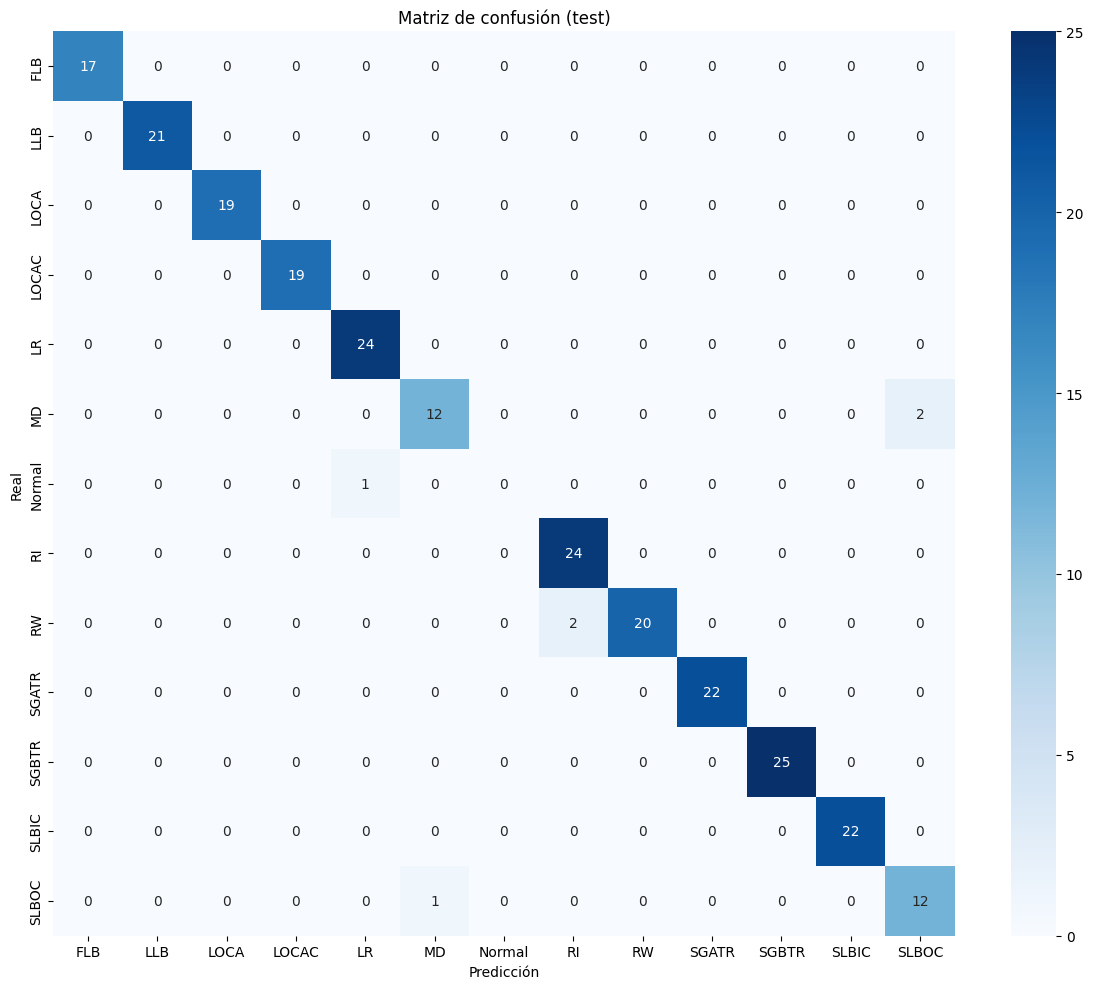

In [3]:
print("\n=== Evaluación del modelo ===")
y_pred = modelo.predict(X_test_top)

# Accuracy global
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {accuracy:.4f}")

# Classification Report (solo clases presentes en test)
unique_labels = np.unique(y_test)
target_names_subset = le.classes_[unique_labels]

print("\nClassification Report (clases en test):")
print(classification_report(
    y_test, y_pred,
    labels=unique_labels,
    target_names=target_names_subset
))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names_subset,
    yticklabels=target_names_subset
)
plt.title('Matriz de confusión (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig("../results/imagenes/matriz_confusion.png", dpi=150)
plt.show()

**Observación**: El modelo tiene una alta precisión global, pero se observa un bajo rendimiento en clases con muy pocas muestras (ej. `Normal` o `SLBOC`). Esto es esperable y se debe al desbalanceo del dataset.

## 4. Interpretación con SHAP
SHAP (SHapley Additive exPlanations) nos permite descomponer la predicción de cada muestra en contribuciones individuales de cada característica. Así podemos ver:

* Qué características son más importantes globalmente.
* Cómo influye cada característica en una predicción concreta (waterfall plot).

**Limitación técnica**: SHAP es computacionalmente costoso, por lo que trabajamos con un subconjunto de 200 muestras de test.

In [4]:
# Filtrar clases no conocidas por el modelo (por si acaso)
clases_modelo = modelo.classes_
mask = np.isin(y_test, clases_modelo)
X_test_filtrado = X_test_top[mask]
y_test_filtrado = y_test[mask]

# Subconjunto de 200 muestras
sample_size = min(200, len(X_test_filtrado))
X_sample = X_test_filtrado.iloc[:sample_size]
y_sample = y_test_filtrado[:sample_size]

# Calcular SHAP values
explainer, shap_values = calcular_shap_values(modelo, X_sample)
print(f"SHAP values calculados para {len(X_sample)} muestras.")

# Predicciones sobre X_sample (para identificar muestras bien/mal clasificadas)
y_pred_sample = modelo.predict(X_sample)

SHAP values calculados para 200 muestras.


### 4.1. Muestra bien clasificada con mayor confianza
Seleccionamos la muestra bien clasificada con mayor probabilidad (confianza) y generamos un waterfall plot que explica por qué el modelo acertó.


Muestra con mayor confianza: LOCAC (probabilidad 1.0000)


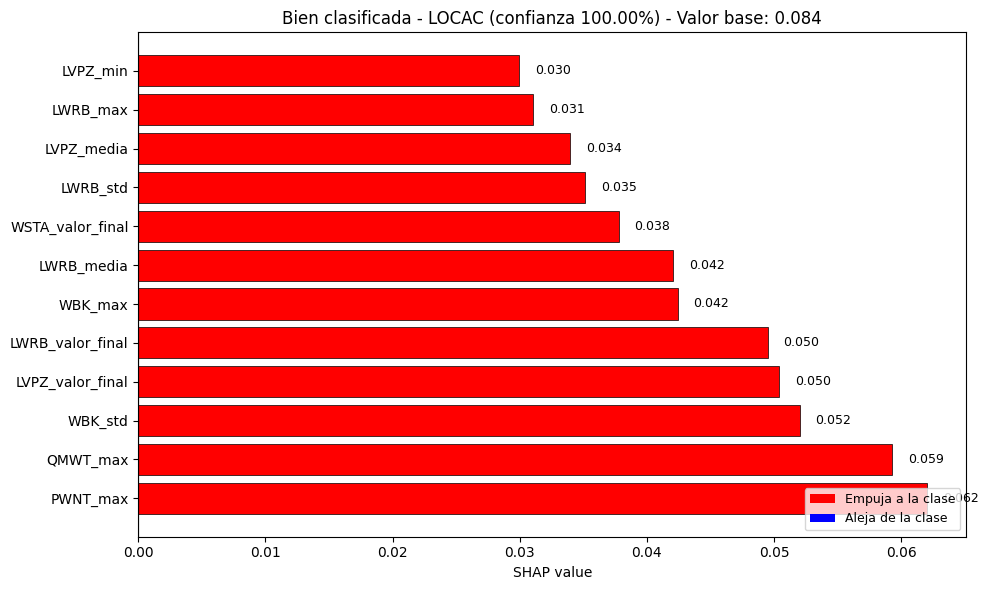

In [5]:
correct_indices = np.where(y_pred_sample == y_sample)[0]

if len(correct_indices) > 0:
    probs = modelo.predict_proba(X_sample)
    probs_real = np.array([probs[i, y_sample[i]] for i in correct_indices])
    idx_max = correct_indices[np.argmax(probs_real)]
    clase_real = y_sample[idx_max]
    clase_real_nombre = le.classes_[clase_real]
    prob_max = probs_real[np.argmax(probs_real)]

    print(f"\nMuestra con mayor confianza: {clase_real_nombre} (probabilidad {prob_max:.4f})")

    fig, ax = plot_waterfall(
        shap_values,
        X_sample,
        idx_max,
        clase_real,
        X_sample.columns.tolist(),
        explainer.expected_value,
        top_n=12,
        title=f"Bien clasificada - {clase_real_nombre} (confianza {prob_max:.2%})"
    )
    plt.savefig("../results/imagenes/shap_waterfall_bien.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay muestras bien clasificadas en el subconjunto.")

**Interpretación**: En el waterfall plot, las barras rojas empujan la predicción hacia la clase predicha, mientras que las azules la alejan. Para una muestra bien clasificada, las barras rojas deberían dominar, indicando que el modelo ha encontrado señales claras.



### 4.2. Muestra mal clasificada
Seleccionamos la primera muestra mal clasificada y generamos un waterfall plot para la clase predicha (no la real). Esto nos ayuda a entender por qué el modelo se equivocó.


Muestra mal clasificada: Real=MD, Pred=SLBOC


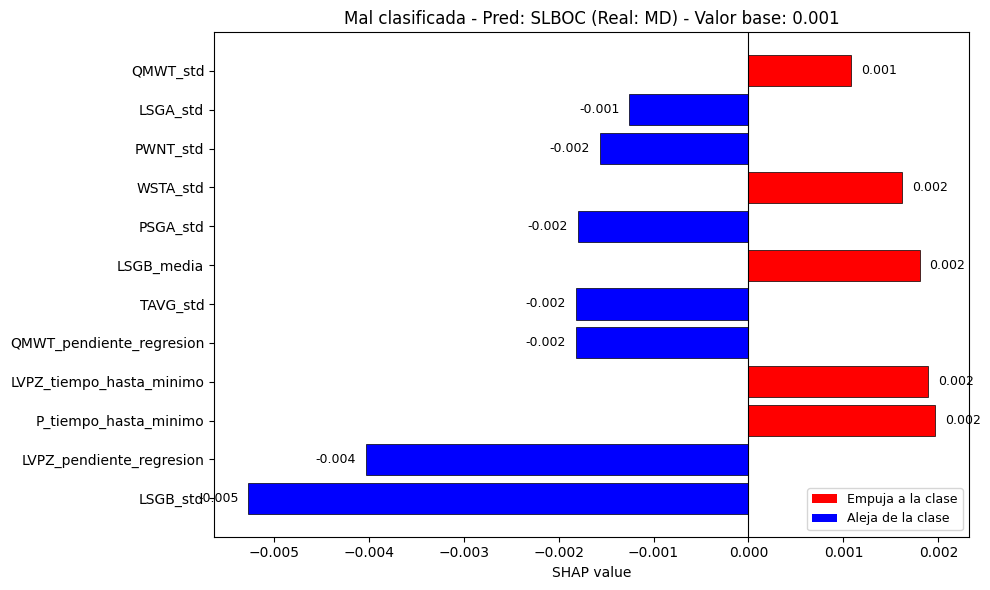

In [6]:
incorrect_indices = np.where(y_pred_sample != y_sample)[0]

if len(incorrect_indices) > 0:
    idx_incorrect = incorrect_indices[0]
    clase_real = y_sample[idx_incorrect]
    clase_pred = y_pred_sample[idx_incorrect]
    clase_real_nombre = le.classes_[clase_real]
    clase_pred_nombre = le.classes_[clase_pred]

    print(f"\nMuestra mal clasificada: Real={clase_real_nombre}, Pred={clase_pred_nombre}")

    fig, ax = plot_waterfall(
        shap_values,
        X_sample,
        idx_incorrect,
        clase_pred,  # Explicamos la clase predicha
        X_sample.columns.tolist(),
        explainer.expected_value,
        top_n=12,
        title=f"Mal clasificada - Pred: {clase_pred_nombre} (Real: {clase_real_nombre})"
    )
    plt.savefig("../results/imagenes/shap_waterfall_mal.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo hay muestras mal clasificadas en el subconjunto.")

**Interpretación**: En una muestra mal clasificada, veremos barras rojas que empujan hacia la clase incorrecta (la predicha) y barras azules que deberían haber empujado hacia la real pero no fueron suficientemente fuertes.

## 5. Análisis de confusiones
A continuación, listamos las confusiones reales que ha cometido el modelo en el conjunto de test (solo aquellas con count > 0):

In [7]:
print("\n=== Análisis de confusiones (solo confusiones > 0) ===")
cm_df = pd.DataFrame(cm, index=target_names_subset, columns=target_names_subset)

for class_name in target_names_subset:
    row = cm_df.loc[class_name]
    sorted_preds = row.sort_values(ascending=False)
    for pred_class, count in sorted_preds.items():
        if pred_class != class_name and count > 0:
            print(f"Clase '{class_name}' se confunde con '{pred_class}': {count} veces")


=== Análisis de confusiones (solo confusiones > 0) ===
Clase 'MD' se confunde con 'SLBOC': 2 veces
Clase 'Normal' se confunde con 'LR': 1 veces
Clase 'RW' se confunde con 'RI': 2 veces
Clase 'SLBOC' se confunde con 'MD': 1 veces


### 5.1. Interpretación de las confusiones

#### MD (Moderator Dilution) ↔ SLBOC (Steam Line Break Outside Containment)
- **MD**: Inyección de agua sin boro en el primario → aumento de reactividad y potencia. Afecta a temperatura, presión y flujo neutrónico.
- **SLBOC**: Rotura de línea de vapor fuera de contención → pérdida de refrigerante en el secundario, caída de presión en el generador de vapor y cambios en el nivel de agua.
- **¿Por qué se confunden?** Aunque son accidentes de naturaleza muy distinta (reactividad vs. pérdida de refrigerante en el secundario), ambos pueden provocar variaciones en la presión del primario y en los niveles de los generadores de vapor. El modelo confunde `MD` con `SLBOC` en 2 ocasiones, mientras que `SLBOC` solo se confunde con `MD` en 1 ocasión. Esto indica que los patrones de `MD` son más difíciles de distinguir y se solapan más con `SLBOC` que al revés. Posiblemente, las muestras de `MD` con baja severidad generan señales menos extremas que se asemejan a una fuga pequeña en el secundario.

#### Normal ↔ LR (Load Rejection)
- **Normal**: Operación sin accidentes. Parámetros estables.
- **LR**: Pérdida de carga en la turbina → transitorio de presión y temperatura en el primario.
- **¿Por qué se confunden?** Una pérdida de carga pequeña puede generar un transitorio suave que el modelo interpreta como operación normal. La confusión es solo de 1 muestra, lo que indica que el modelo distingue bien en general.

#### RW (Rod Withdrawal) ↔ RI (Rod Insertion)
- **RW**: Extracción de barras de control → aumento de reactividad y potencia.
- **RI**: Inserción de barras de control → disminución de reactividad y potencia.
- **¿Por qué se confunden?** Ambos son accidentes de reactividad, con patrones opuestos pero que afectan a las mismas variables (potencia, flujo neutrónico, temperatura). El modelo confunde `RW` con `RI` en 2 ocasiones, pero `RI` no se confunde con `RW`. Esto sugiere que la extracción de barras (RW) tiene patrones más difíciles de clasificar que la inserción (RI), quizás porque la respuesta de la planta a la extracción es más rápida o más variable.

### 5.2. Implicaciones para la mejora del modelo

Para reducir estas confusiones, se podría:
1. **Incluir sensores más específicos**
2. **Añadir características de derivada temporal** (cambios rápidos) para distinguir transitorios de pérdida de carga de operación normal.
3. **Recolectar más datos** de las clases con menor representación (`MD`, `LR`, `RW`) para que el modelo tenga más ejemplos de sus patrones.

## 6. Conclusiones

* El modelo alcanza una **accuracy en test > 97%**, confirmando su alta capacidad predictiva.

* El análisis SHAP revela que características como `P_media`, `WBK_max`, `TAVG_pendiente` y `LVPZ_min` son las más influyentes, lo cual es coherente con la física de los accidentes (presión, flujo de rotura, temperatura y nivel del presurizador).

* Las confusiones ocurren principalmente en clases con pocas muestras o físicamente similares, lo que sugiere la necesidad de más datos de esas clases para mejorar el modelo.

* La interpretación con SHAP es clave para generar confianza en el modelo, ya que permite explicar cada predicción de forma transparente.

**Próximos pasos**: En un entorno real, se podría:

* Incorporar más datos de clases minoritarias.
* Calibrar las probabilidades para que sean más realistas (evitando extremos como 1.0).
* Validar el modelo con datos de planta (no simulados) para evaluar su robustez.